In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from warnings import filterwarnings

filterwarnings("ignore")

%matplotlib inline

In [2]:
f_p = "../artifacts/datasets/EasyVisa.csv"

In [3]:
df = pd.read_csv(f_p)

In [4]:
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [5]:
df.describe().style.format("{:.0f}")

,no_of_employees,yr_of_estab,prevailing_wage
count,25480,25480,25480
mean,5667,1979,74456
std,22878,42,52816
min,-26,1800,2
25%,1022,1976,34015
50%,2109,1997,70308
75%,3504,2005,107736
max,602069,2016,319210


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  str    
 1   continent              25480 non-null  str    
 2   education_of_employee  25480 non-null  str    
 3   has_job_experience     25480 non-null  str    
 4   requires_job_training  25480 non-null  str    
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  str    
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  str    
 10  full_time_position     25480 non-null  str    
 11  case_status            25480 non-null  str    
dtypes: float64(1), int64(2), str(9)
memory usage: 2.3 MB


In [7]:
cat_feat = [x for x in df.columns if df[x].dtype == "str"]
num_feat = [x for x in df.columns if df[x].dtype != "str"]

In [8]:
for col in cat_feat:
    print(df[col].value_counts(normalize=True)* 100)
    print("-"*100)
    print("\n")

case_id
EZYV01       0.003925
EZYV02       0.003925
EZYV03       0.003925
EZYV04       0.003925
EZYV05       0.003925
               ...   
EZYV25476    0.003925
EZYV25477    0.003925
EZYV25478    0.003925
EZYV25479    0.003925
EZYV25480    0.003925
Name: proportion, Length: 25480, dtype: float64
----------------------------------------------------------------------------------------------------


continent
Asia             66.173469
Europe           14.646782
North America    12.919937
South America     3.343799
Africa            2.162480
Oceania           0.753532
Name: proportion, dtype: float64
----------------------------------------------------------------------------------------------------


education_of_employee
Bachelor's     40.164835
Master's       37.810047
High School    13.422292
Doctorate       8.602826
Name: proportion, dtype: float64
----------------------------------------------------------------------------------------------------


has_job_experience
Y    58.092622

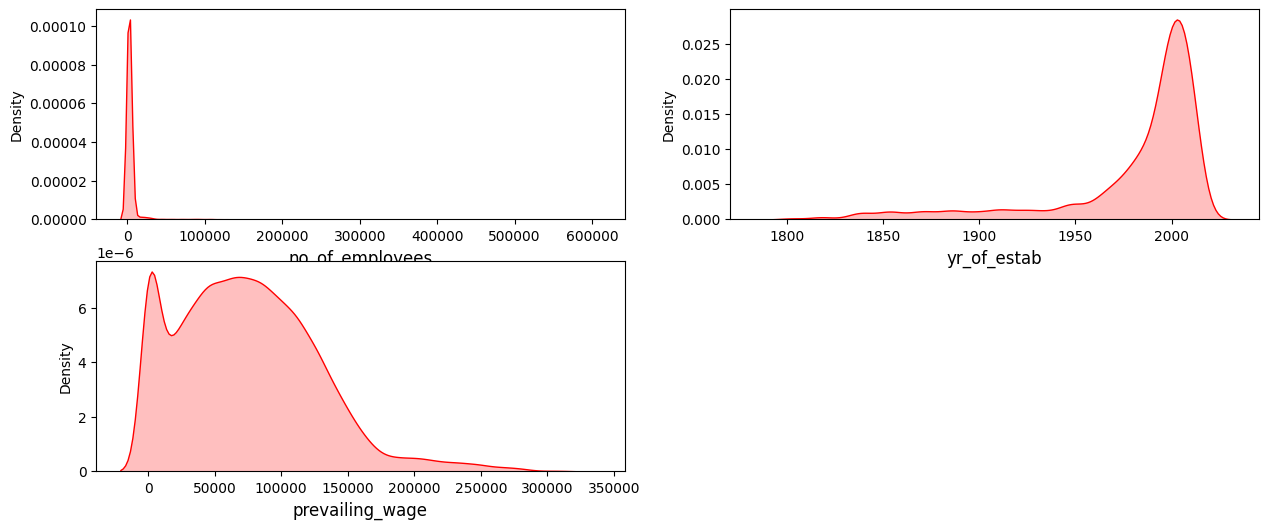

In [9]:
plt.figure(figsize=(15,6))

for i in range(0, len(num_feat)):
    plt.subplot(2,2, i+1)
    sns.kdeplot(x=num_feat[i], data=df, color="red", fill=True)
    plt.xlabel(num_feat[i], fontsize=12)